In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter
from scipy import special
from scipy.optimize import lsq_linear
import pickle

# Physical constants
h_SI = 6.62607015e-34
kB = 1.380649e-23

# Model constants
TC_NB = 9.2
GAMMA_NB = 1e-6
DEFAULT_F_RES = 5.5e9

In [9]:
import sys; sys.path.append("..")
from data.curated_data import data_dict as stress_resonators

# Remove non-sample entries if present.
stress_resonators = dict(stress_resonators)
for _key in ["Sample N", "All Film"]:
    stress_resonators.pop(_key, None)

print(stress_resonators.keys())

dict_keys(['Sample A', 'Sample B', 'Sample C', 'Sample D', 'Sample E'])


In [10]:
with open("../data/res_vs_temp_fits.pkl", "rb") as file:
    fixed_results = pickle.load(file)

In [11]:
# ============================================================
# Physics helper functions
# ============================================================

def tls_tanh_loss_shape(T_mK, f_res):
    """TLS loss temperature factor tanh(hf/2kBT)."""
    T_K = np.asarray(T_mK, dtype=float) * 1e-3
    x = h_SI * np.asarray(f_res, dtype=float) / (2 * kB * np.maximum(T_K, 1e-12))
    return np.tanh(np.clip(x, 1e-12, 500))


def bcs_gap_D(T_mK, Tc, Gamma_ratio=0.0):
    """
    Return Dynes-broadened gap D(T) in Joules.

    D0 = 1.764 kB Tc
    D_BCS(T) = D0 tanh[1.74 sqrt(Tc/T - 1)] for T<Tc
    D(T) = sqrt(D_BCS^2 + Gamma^2), Gamma = Gamma_ratio*D0
    """
    T = np.asarray(T_mK, dtype=float) * 1e-3
    T = np.maximum(T, 1e-9)

    D0 = 1.764 * kB * Tc
    Gamma = Gamma_ratio * D0

    rat = Tc / T
    D_bcs = np.where(
        rat > 1,
        D0 * np.tanh(1.74 * np.sqrt(np.clip(rat - 1, 0, None))),
        0.0,
    )
    return np.sqrt(D_bcs**2 + Gamma**2)


def mb_sigma1_norm(T_mK, Tc, f_res, Gamma_ratio=0.0):
    """
    Approximate Mattis-Bardeen sigma1/sigma_n shape used by the fit.

    This is not the full integral form; it is the low-temperature MB-like
    expression used in the original fitting code plus a Dynes residual term.
    """
    T = np.asarray(T_mK, dtype=float) * 1e-3
    f = np.asarray(f_res, dtype=float)
    T = np.maximum(T, 1e-9)

    D = bcs_gap_D(T_mK, Tc, Gamma_ratio=Gamma_ratio)
    hw = h_SI * f
    D0 = 1.764 * kB * Tc
    Gamma = Gamma_ratio * D0

    eta = np.clip(hw / (2 * kB * T), 1e-12, 500)
    dkT = np.clip(D / (kB * T), 0, 500)

    s1_th = (4 * D / hw) * np.exp(-dkT) * np.sinh(eta) * special.k0(eta)
    s1_dy = (Gamma / np.maximum(D, 1e-30))**2

    return np.minimum(s1_th + s1_dy, 1.0)


def mb_sigma2_norm(T_mK, Tc, f_res, Gamma_ratio=0.0):
    """
    Approximate Mattis-Bardeen sigma2/sigma_n shape used by the fit.

    Uses the same Dynes-broadened gap convention as sigma1 for consistency.
    """
    T = np.asarray(T_mK, dtype=float) * 1e-3
    f = np.asarray(f_res, dtype=float)
    T = np.maximum(T, 1e-9)

    D = bcs_gap_D(T_mK, Tc, Gamma_ratio=Gamma_ratio)
    hw = h_SI * f

    arg = np.clip(D / (2 * kB * T), 1e-12, 500)
    return (np.pi * D / hw) * np.tanh(arg)


def mb_loss_shape(T_mK, Tc, Gamma_ratio, f_res):
    """Loss shape sigma1/sigma2 for one superconducting component."""
    s1 = mb_sigma1_norm(T_mK, Tc, f_res, Gamma_ratio=Gamma_ratio)
    s2 = mb_sigma2_norm(T_mK, Tc, f_res, Gamma_ratio=Gamma_ratio)
    return s1 / np.maximum(s2, 1e-30)


def tls_freq_shape(T_mK, f_res):
    """Standard TLS frequency-dispersion shape."""
    T = np.asarray(T_mK, dtype=float) * 1e-3
    f = np.asarray(f_res, dtype=float)
    arg = h_SI * f / (2 * np.pi * kB * np.maximum(T, 1e-12))
    z = 0.5 + 1j * arg
    return np.real(special.digamma(z)) - np.log(arg)


def ki_shape(T_mK, Tref_mK, Tc2, f_res, Gamma_ratio=0.0):
    """
    Secondary-component kinetic-inductance-like shape.

    Positive for T > Tref when sigma2 decreases with T. In the frequency model
    it appears with a minus sign: -B_KI * ki_shape.
    """
    s2_T = mb_sigma2_norm(T_mK, Tc2, f_res, Gamma_ratio=Gamma_ratio)
    s2_R = mb_sigma2_norm(Tref_mK, Tc2, f_res, Gamma_ratio=Gamma_ratio)
    return s2_R / np.maximum(s2_T, 1e-30) - 1.0

In [12]:
# ============================================================
# Plot resonator-level loss and frequency fits
# ============================================================

def _param_value(params, kind, name, default=0.0):
    q = params[(params["kind"] == kind) & (params["name"] == name)]
    return float(q["value"].iloc[0]) if len(q) else default


def plot_loss_freq_fixed_Tc2_fits(
    fixed_results,
    figsize=(16, 6),
    cmap_name="plasma",
    savepath=None,
    scale_Qi_by=1.0,
    local_y_limits=True,
):
    """
    Plot resonator-level loss and frequency fits.

    Top row: Qi(T) loss fits.
    Bottom row: df/f(T) frequency fits.

    Uses the same color for each resonator in the loss and frequency panels.
    """

    title_fs = 13
    label_fs = 16
    tick_fs = 10
    legend_fs = 9

    loss_fit = fixed_results["loss_profile"]["best_fit"]
    freq_fit = fixed_results["freq_fixed"]

    loss_df = loss_fit["df"]
    freq_df = freq_fit["df"]

    samples = sorted(
        loss_df["sample"].unique(),
        key=lambda s: loss_df[loss_df["sample"] == s]["stress"].iloc[0],
    )

    fig, axs = plt.subplots(
        2,
        len(samples),
        figsize=figsize,
        sharex=True,
        sharey=False,
        constrained_layout=False,
    )

    if len(samples) == 1:
        axs = np.array([[axs[0]], [axs[1]]])

    cmap = cm.get_cmap(cmap_name)

    for i, sample in enumerate(samples):
        res_ids_loss = set(loss_df[loss_df["sample"] == sample]["res_id"].unique())
        res_ids_freq = set(freq_df[freq_df["sample"] == sample]["res_id"].unique())
        res_ids = sorted(res_ids_loss | res_ids_freq)

        colors = cmap(np.linspace(0.12, 0.88, max(len(res_ids), 1)))
        color_map = dict(zip(res_ids, colors))

        # -------------------------------
        # Top row: loss
        # -------------------------------
        ax = axs[0, i]
        df_s = loss_df[loss_df["sample"] == sample]
        stress = df_s["stress"].iloc[0]

        for res_id in res_ids:
            df_r = df_s[df_s["res_id"] == res_id].sort_values("T_mK")
            if len(df_r) == 0:
                continue

            color = color_map[res_id]
            label = res_id.split("::")[-1]

            Qi = 1.0 / df_r["invQ"].to_numpy(float)
            Qi_err = df_r["invQ_err"].to_numpy(float) / df_r["invQ"].to_numpy(float)**2

            ax.errorbar(
                df_r["T_mK"],
                Qi / scale_Qi_by,
                yerr=Qi_err / scale_Qi_by,
                fmt="o",
                ms=6,
                capsize=2,
                color=color,
                ecolor=color,
                alpha=0.85,
                label=label,
            )

            T_dense = np.linspace(df_r["T_mK"].min(), df_r["T_mK"].max(), 800)
            f_res = df_r["f_res"].median()

            Cj = _param_value(loss_fit["params"], "C_res", res_id)
            A_tls = _param_value(loss_fit["params"], "A_TLS", sample)
            A_sec = _param_value(loss_fit["params"], "A_secondary", sample)

            invQ_fit = (
                Cj
                + A_tls * tls_tanh_loss_shape(T_dense, f_res)
                + A_sec * mb_loss_shape(T_dense, loss_fit["Tc2"], loss_fit["Gamma"], f_res)
                + mb_loss_shape(T_dense, TC_NB, GAMMA_NB, f_res)
            )

            ax.plot(
                T_dense,
                (1.0 / invQ_fit) / scale_Qi_by,
                "-",
                lw=2.0,
                color=color,
                alpha=0.95,
            )

        ax.set_yscale("log")
        ax.set_title(
        f"{sample}",
        fontsize=title_fs,
        pad=6,
        )
        ax.grid(alpha=0.22, which="both")
        ax.tick_params(
                    direction="in",
                    top=True,
                    right=True,
                    labelsize=tick_fs,
                )
        
        if i == 0:
            if scale_Qi_by == 1.0:
                ax.set_ylabel(r"$Q_i$", fontsize=label_fs)
            else:
                ax.set_ylabel(rf"$Q_i / {scale_Qi_by:.0e}$")
        else:
            ax.set_ylabel("")

        if i == 1:

            ax.legend(
        
                fontsize=legend_fs,
        
                frameon=True,
        
                loc="best",
        
                handlelength=1.5,
        
                borderpad=0.3,
        
            )

        # -------------------------------
        # Bottom row: frequency
        # -------------------------------
        ax = axs[1, i]
        df_s = freq_df[freq_df["sample"] == sample]

        for res_id in res_ids:
            df_r = df_s[df_s["res_id"] == res_id].sort_values("T_mK")
            if len(df_r) == 0:
                continue

            color = color_map[res_id]
            label = res_id.split("::")[-1]

            ax.errorbar(
                df_r["T_mK"],
                1e6 * df_r["dff"],
                yerr=1e6 * df_r["dff_err"],
                fmt="o",
                ms=4,
                capsize=2,
                color=color,
                ecolor=color,
                alpha=0.85,
                label=label,
            )

            T_dense = np.linspace(df_r["T_mK"].min(), df_r["T_mK"].max(), 800)
            Tref = df_r["Tref_mK"].iloc[0]
            f_res = df_r["f_res"].median()

            offset = _param_value(freq_fit["params"], "offset", res_id)
            B_tls = _param_value(freq_fit["params"], "B_TLS", sample)
            B_ki = _param_value(freq_fit["params"], "B_KI", sample)

            dff_fit = (
                offset
                + B_tls * (tls_freq_shape(T_dense, f_res) - tls_freq_shape(Tref, f_res))
                - B_ki * ki_shape(
                    T_dense,
                    Tref,
                    freq_fit["Tc2"],
                    f_res,
                    Gamma_ratio=freq_fit["Gamma"],
                )
            )

            ax.plot(
                T_dense,
                1e6 * dff_fit,
                "-",
                lw=2.0,
                color=color,
                alpha=0.95,
            )

        ax.axhline(0, color="0.25", ls="--", lw=0.9)
        ax.set_xlabel(
                    "Temperature [mK]",
                    fontsize=label_fs,
                )
        ax.grid(alpha=0.22)
        ax.tick_params(direction="in", top=True, right=True)

        if i == 0:
            ax.set_ylabel(
                        r"$\Delta f/f_0$ [ppm]",
                        fontsize=label_fs,
                    )
        else:
            ax.set_ylabel("")

    # Avoid offset text collision in multi-panel plots.
    for ax in axs.flat:
        ax.yaxis.get_offset_text().set_fontsize(7)

    # fig.suptitle(
    #     rf"Loss-constrained frequency fit: "
    #     rf"$T_{{c,2}}={fixed_results['Tc2_fixed']:.2f}$ K",
    #     y=0.98,
    #     fontsize=13,
    # )

    fig.subplots_adjust(
        left=0.06,
        right=0.995,
        bottom=0.11,
        top=0.82,
        wspace=0.28,
        hspace=0.25,
    )

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
        if savepath.lower().endswith(".png"):
            fig.savefig(savepath[:-4] + ".pdf", bbox_inches="tight")

    return fig

In [17]:
# ============================================================
# Fitting functions
# ============================================================

def _sorted_samples_by_stress(df):
    return sorted(df["sample"].unique(), key=lambda s: df[df["sample"] == s]["stress"].iloc[0])


def fit_loss_fixed_Tc(
    loss_df,
    Tc2,
    Gamma_fix=1e-6,
    include_tls=True,
    include_secondary=True,
):
    """
    Linear loss fit at fixed Tc2.

        invQ = C_j + A_TLS_s*g_TLS + A_sec_s*g_sec(Tc2) + g_Nb

    Non-negative bounds are used for C_j, A_TLS_s, and A_sec_s.
    """
    samples = _sorted_samples_by_stress(loss_df)
    res_ids = sorted(loss_df["res_id"].unique())

    y = loss_df["invQ"].to_numpy(float)
    err = loss_df["invQ_err"].to_numpy(float)
    T = loss_df["T_mK"].to_numpy(float)
    f = loss_df["f_res"].to_numpy(float)

    cols, names, lower, upper = [], [], [], []

    # Per-resonator constant loss
    for r in res_ids:
        cols.append((loss_df["res_id"].to_numpy() == r).astype(float))
        names.append(("C_res", r))
        lower.append(0.0)
        upper.append(np.inf)

    # Per-sample TLS amplitude
    if include_tls:
        g_tls = tls_tanh_loss_shape(T, f)
        for s in samples:
            cols.append(g_tls * (loss_df["sample"].to_numpy() == s))
            names.append(("A_TLS", s))
            lower.append(0.0)
            upper.append(np.inf)

    # Per-sample secondary loss amplitude
    if include_secondary:
        g_sec = mb_loss_shape(T, Tc2, Gamma_fix, f)
        for s in samples:
            cols.append(g_sec * (loss_df["sample"].to_numpy() == s))
            names.append(("A_secondary", s))
            lower.append(0.0)
            upper.append(np.inf)

    # Fixed conventional Nb loss contribution
    y_fixed = mb_loss_shape(T, TC_NB, GAMMA_NB, f)
    y_target = y - y_fixed

    X = np.vstack(cols).T
    Xw = X / err[:, None]
    yw = y_target / err

    sol = lsq_linear(
        Xw,
        yw,
        bounds=(np.asarray(lower), np.asarray(upper)),
        method="trf",
    )

    yfit = X @ sol.x + y_fixed
    chi2 = float(np.sum(((y - yfit) / err)**2))
    npar = len(sol.x)
    npts = len(y)
    dof = npts - npar

    params = pd.DataFrame({
        "kind": [n[0] for n in names],
        "name": [n[1] for n in names],
        "value": sol.x,
    })

    out_df = loss_df.copy()
    out_df["fit_invQ"] = yfit
    out_df["fit_Qi"] = 1.0 / yfit
    out_df["resid"] = (out_df["invQ"] - out_df["fit_invQ"]) / out_df["invQ_err"]

    return {
        "success": bool(sol.success),
        "Tc2": float(Tc2),
        "Gamma": float(Gamma_fix),
        "chi2": chi2,
        "npts": npts,
        "npar": npar,
        "dof": dof,
        "AIC": chi2 + 2*npar,
        "BIC": chi2 + npar*np.log(npts),
        "params": params,
        "df": out_df,
    }


def profile_loss_Tc2(
    loss_df,
    Tc2_grid=np.linspace(1.0, 4.5, 160),
    Gamma_fix=1e-6,
    include_tls=True,
):
    """Profile the loss fit over Tc2."""
    fits = {}
    rows = []

    for Tc2 in Tc2_grid:
        fit = fit_loss_fixed_Tc(
            loss_df,
            Tc2=Tc2,
            Gamma_fix=Gamma_fix,
            include_tls=include_tls,
            include_secondary=True,
        )
        fits[float(Tc2)] = fit
        rows.append({
            "Tc2": float(Tc2),
            "chi2": fit["chi2"],
            "AIC": fit["AIC"],
            "BIC": fit["BIC"],
        })

    prof = pd.DataFrame(rows)
    prof["delta_chi2"] = prof["chi2"] - prof["chi2"].min()

    best_Tc2 = float(prof.loc[prof["chi2"].idxmin(), "Tc2"])
    best_fit = fits[best_Tc2]

    inside = prof[prof["delta_chi2"] <= 1.0]
    if len(inside):
        Tc_lo = float(inside["Tc2"].min())
        Tc_hi = float(inside["Tc2"].max())
        sigma = 0.5 * (Tc_hi - Tc_lo)
    else:
        Tc_lo = np.nan
        Tc_hi = np.nan
        sigma = np.nan

    return {
        "profile": prof,
        "fits": fits,
        "best_Tc2": best_Tc2,
        "Tc2_1sigma": (Tc_lo, Tc_hi),
        "Tc2_sigma": sigma,
        "best_fit": best_fit,
    }


def fit_freq_fixed_Tc(
    freq_df,
    Tc2,
    include_tls=True,
    include_ki=True,
    Gamma_fix=1e-6,
    include_offsets=False,
):
    """
    Linear frequency-shift fit at fixed Tc2.

        dff = D_j + B_TLS_s*Delta h_TLS - B_KI_s*k_sec(Tc2)

    B_KI is constrained positive because the minus sign is included in the
    design matrix.
    """
    samples = _sorted_samples_by_stress(freq_df)
    res_ids = sorted(freq_df["res_id"].unique())

    y = freq_df["dff"].to_numpy(float)
    err = freq_df["dff_err"].to_numpy(float)
    T = freq_df["T_mK"].to_numpy(float)
    Tref = freq_df["Tref_mK"].to_numpy(float)
    f = freq_df["f_res"].to_numpy(float)

    cols, names, lower, upper = [], [], [], []

    # Optional per-resonator offsets
    if include_offsets:
        for r in res_ids:
            cols.append((freq_df["res_id"].to_numpy() == r).astype(float))
            names.append(("offset", r))
            lower.append(-np.inf)
            upper.append(np.inf)

    # Per-sample TLS dispersion amplitude
    if include_tls:
        g_tls = tls_freq_shape(T, f) - tls_freq_shape(Tref, f)
        for s in samples:
            cols.append(g_tls * (freq_df["sample"].to_numpy() == s))
            names.append(("B_TLS", s))
            lower.append(-np.inf)
            upper.append(np.inf)

    # Per-sample kinetic-inductance-like amplitude.
    # The minus sign is part of the basis function, so B_KI >= 0.
    if include_ki:
        g_ki = -ki_shape(
            T,
            Tref,
            Tc2,
            f,
            Gamma_ratio=Gamma_fix,
        )
        for s in samples:
            cols.append(g_ki * (freq_df["sample"].to_numpy() == s))
            names.append(("B_KI", s))
            lower.append(0.0)
            upper.append(np.inf)

    if len(cols) == 0:
        raise ValueError("No columns in frequency design matrix.")

    X = np.vstack(cols).T
    Xw = X / err[:, None]
    yw = y / err

    sol = lsq_linear(
        Xw,
        yw,
        bounds=(np.asarray(lower), np.asarray(upper)),
        method="trf",
    )

    yfit = X @ sol.x
    chi2 = float(np.sum(((y - yfit) / err)**2))
    npar = len(sol.x)
    npts = len(y)
    dof = npts - npar

    params = pd.DataFrame({
        "kind": [n[0] for n in names],
        "name": [n[1] for n in names],
        "value": sol.x,
    })

    out_df = freq_df.copy()
    out_df["fit_dff"] = yfit
    out_df["resid"] = (out_df["dff"] - out_df["fit_dff"]) / out_df["dff_err"]

    return {
        "success": bool(sol.success),
        "Tc2": float(Tc2),
        "Gamma": float(Gamma_fix),
        "include_offsets": bool(include_offsets),
        "chi2": chi2,
        "npts": npts,
        "npar": npar,
        "dof": dof,
        "AIC": chi2 + 2*npar,
        "BIC": chi2 + npar*np.log(npts),
        "params": params,
        "df": out_df,
    }


def run_loss_then_frequency_fixed_Tc2(
    stress_resonators,
    T_max=1000,
    loss_frac_floor=0.08,
    freq_frac_floor=0.05,
    freq_abs_floor=1e-7,
    Gamma_fix=1e-6,
    Tc2_grid=np.linspace(1.0, 4.5, 180),
    Tc2_fixed=None,
    Tref_target_mK=200.0,
    Tref_window_mK=60.0,
    include_offsets=False,
):
    """
    Main analysis wrapper.

    1. Build loss and frequency dataframes.
    2. Profile loss over Tc2.
    3. Fix Tc2 to the loss best fit unless Tc2_fixed is supplied.
    4. Fit frequency at fixed Tc2.
    """
    loss_df = build_lossT_df(
        stress_resonators,
        T_max=T_max,
        frac_floor=loss_frac_floor,
    )

    freq_df = build_freqT_df(
        stress_resonators,
        T_max=T_max,
        frac_floor=freq_frac_floor,
        abs_floor=freq_abs_floor,
        Tref_target_mK=Tref_target_mK,
        Tref_window_mK=Tref_window_mK,
    )

    loss_profile = profile_loss_Tc2(
        loss_df,
        Tc2_grid=Tc2_grid,
        Gamma_fix=Gamma_fix,
        include_tls=True,
    )

    Tc2_loss = loss_profile["best_Tc2"]
    if Tc2_fixed is None:
        Tc2_fixed = Tc2_loss

    freq_fixed = fit_freq_fixed_Tc(
        freq_df,
        Tc2=Tc2_fixed,
        include_tls=True,
        include_ki=True,
        Gamma_fix=Gamma_fix,
        include_offsets=include_offsets,
    )

    freq_tls_only = fit_freq_fixed_Tc(
        freq_df,
        Tc2=Tc2_fixed,
        include_tls=True,
        include_ki=False,
        Gamma_fix=Gamma_fix,
        include_offsets=include_offsets,
    )

    freq_ki_only = fit_freq_fixed_Tc(
        freq_df,
        Tc2=Tc2_fixed,
        include_tls=False,
        include_ki=True,
        Gamma_fix=Gamma_fix,
        include_offsets=include_offsets,
    )

    freq_compare = pd.DataFrame([
        {
            "model": "TLS only",
            "chi2": freq_tls_only["chi2"],
            "dof": freq_tls_only["dof"],
            "chi2_red": freq_tls_only["chi2"] / max(freq_tls_only["dof"], 1),
            "AIC": freq_tls_only["AIC"],
            "BIC": freq_tls_only["BIC"],
        },
        {
            "model": "KI only",
            "chi2": freq_ki_only["chi2"],
            "dof": freq_ki_only["dof"],
            "chi2_red": freq_ki_only["chi2"] / max(freq_ki_only["dof"], 1),
            "AIC": freq_ki_only["AIC"],
            "BIC": freq_ki_only["BIC"],
        },
        {
            "model": "TLS + KI",
            "chi2": freq_fixed["chi2"],
            "dof": freq_fixed["dof"],
            "chi2_red": freq_fixed["chi2"] / max(freq_fixed["dof"], 1),
            "AIC": freq_fixed["AIC"],
            "BIC": freq_fixed["BIC"],
        },
    ])

    freq_compare["delta_AIC"] = freq_compare["AIC"] - freq_compare["AIC"].min()
    freq_compare["delta_BIC"] = freq_compare["BIC"] - freq_compare["BIC"].min()

    print("Loss-only Tc2:")
    print(f"  Tc2_loss = {Tc2_loss:.3f} K")
    print(
        f"  profile interval = "
        f"{loss_profile['Tc2_1sigma'][0]:.3f}–"
        f"{loss_profile['Tc2_1sigma'][1]:.3f} K"
    )
    print()
    print("Frequency fit:")
    print(f"  Tc2 fixed = {Tc2_fixed:.3f} K")
    print(f"  chi2_red = {freq_fixed['chi2'] / max(freq_fixed['dof'], 1):.3f}")
    print()
    print(freq_compare.sort_values("AIC"))

    return {
        "loss_df": loss_df,
        "freq_df": freq_df,
        "loss_profile": loss_profile,
        "Tc2_loss": Tc2_loss,
        "Tc2_fixed": float(Tc2_fixed),
        "freq_fixed": freq_fixed,
        "freq_compare": freq_compare,
        "settings": {
            "T_max": T_max,
            "loss_frac_floor": loss_frac_floor,
            "freq_frac_floor": freq_frac_floor,
            "freq_abs_floor": freq_abs_floor,
            "Gamma_fix": Gamma_fix,
            "Tref_target_mK": Tref_target_mK,
            "Tref_window_mK": Tref_window_mK,
            "include_offsets": include_offsets,
        },
    }

In [18]:



def _get_param(params, kind, name, default=np.nan):
    q = params[(params["kind"] == kind) & (params["name"] == name)]
    return float(q["value"].iloc[0]) if len(q) else default


def _fit_freq_fixed_Tc_safe(freq_df, Tc2, Gamma_fix=1e-6, include_tls=True, include_ki=True):
    try:
        return fit_freq_fixed_Tc(
            freq_df,
            Tc2=Tc2,
            include_tls=include_tls,
            include_ki=include_ki,
            Gamma_fix=Gamma_fix,
        )
    except TypeError:
        return fit_freq_fixed_Tc(
            freq_df,
            Tc2=Tc2,
            include_tls=include_tls,
            include_ki=include_ki,
        )


def estimate_amplitude_uncertainties_and_plot(
    fixed_results,
    n_Tc_samples=41,
    delta_chi2_level=1.0,
    cmap_name="plasma",
    figsize=(3.45, 4.4),
    savepath=None,
):
    loss_df = fixed_results["loss_df"]
    freq_df = fixed_results["freq_df"]

    loss_prof = fixed_results["loss_profile"]["profile"]
    Tc_best = fixed_results["Tc2_fixed"]
    Gamma_fix = fixed_results["loss_profile"]["best_fit"].get("Gamma", 1e-6)

    samples = sorted(
        loss_df["sample"].unique(),
        key=lambda s: loss_df[loss_df["sample"] == s]["stress"].iloc[0],
    )

    # ------------------------------------------------------------
    # Tc2 interval from loss profile
    # ------------------------------------------------------------
    inside = loss_prof[loss_prof["delta_chi2"] <= delta_chi2_level]

    if len(inside) >= 2:
        Tc_lo = inside["Tc2"].min()
        Tc_hi = inside["Tc2"].max()
    else:
        Tc_lo = Tc_best - 0.25
        Tc_hi = Tc_best + 0.25
        print("Warning: profile interval not found; using ±0.25 K.")

    Tc_values = np.linspace(Tc_lo, Tc_hi, n_Tc_samples)

    # ------------------------------------------------------------
    # Refit amplitudes over Tc2 range
    # ------------------------------------------------------------
    rows = []

    for Tc2 in Tc_values:
        lf = fit_loss_fixed_Tc(
            loss_df,
            Tc2=Tc2,
            Gamma_fix=Gamma_fix,
            include_tls=True,
            include_secondary=True,
        )

        ff = _fit_freq_fixed_Tc_safe(
            freq_df,
            Tc2=Tc2,
            Gamma_fix=Gamma_fix,
            include_tls=True,
            include_ki=True,
        )

        for sample in samples:
            stress = float(loss_df[loss_df["sample"] == sample]["stress"].iloc[0])

            stress_err = np.nan
            if "stress_err" in loss_df.columns:
                vals = loss_df[loss_df["sample"] == sample]["stress_err"].dropna()
                if len(vals):
                    stress_err = float(vals.iloc[0])

            rows.append({
                "Tc2": Tc2,
                "sample": sample,
                "stress": stress,
                "stress_err": stress_err,
                "A_sec": _get_param(lf["params"], "A_secondary", sample),
                "B_KI": _get_param(ff["params"], "B_KI", sample),
            })

    amp_samples = pd.DataFrame(rows)

    # ------------------------------------------------------------
    # Central values at nominal fixed Tc2
    # ------------------------------------------------------------
    lf0 = fit_loss_fixed_Tc(
        loss_df,
        Tc2=Tc_best,
        Gamma_fix=Gamma_fix,
        include_tls=True,
        include_secondary=True,
    )

    ff0 = _fit_freq_fixed_Tc_safe(
        freq_df,
        Tc2=Tc_best,
        Gamma_fix=Gamma_fix,
        include_tls=True,
        include_ki=True,
    )

    summary_rows = []

    for sample in samples:
        sub = amp_samples[amp_samples["sample"] == sample]

        A0 = _get_param(lf0["params"], "A_secondary", sample)
        B0 = _get_param(ff0["params"], "B_KI", sample)

        summary_rows.append({
            "sample": sample,
            "stress": sub["stress"].iloc[0],
            "stress_err": sub["stress_err"].iloc[0],
            "A_sec": A0,
            "A_sec_lo": np.nanmin(sub["A_sec"]),
            "A_sec_hi": np.nanmax(sub["A_sec"]),
            "B_KI": B0,
            "B_KI_lo": np.nanmin(sub["B_KI"]),
            "B_KI_hi": np.nanmax(sub["B_KI"]),
        })

    summary = pd.DataFrame(summary_rows).sort_values("stress")

    # asymmetric y-errors
    A_yerr = np.vstack([
        summary["A_sec"] - summary["A_sec_lo"],
        summary["A_sec_hi"] - summary["A_sec"],
    ])

    B_yerr = np.vstack([
        summary["B_KI"] - summary["B_KI_lo"],
        summary["B_KI_hi"] - summary["B_KI"],
    ])

    xerr = summary["stress_err"].to_numpy(float)
    xerr = None if np.all(~np.isfinite(xerr)) else xerr

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------
    cmap = mpl.colormaps[cmap_name]
    colors = cmap(np.linspace(0.15, 0.90, len(summary)))

    fig, axs = plt.subplots(
        2, 1,
        figsize=figsize,
        sharex=True,
        constrained_layout=False,
    )

    ax0, ax1 = axs

    for color, (_, row), i in zip(colors, summary.iterrows(), range(len(summary))):
        xi = row["stress"]
        xe = None if xerr is None else row["stress_err"]

        ax0.errorbar(
            xi,
            row["A_sec"],
            xerr=xe,
            yerr=np.array([[row["A_sec"] - row["A_sec_lo"]],
                           [row["A_sec_hi"] - row["A_sec"]]]),
            fmt="o",
            ms=5.5,
            capsize=3,
            lw=1.2,
            color=color,
            ecolor=color,
            zorder=4,
        )

        ax1.errorbar(
            xi,
            row["B_KI"],
            xerr=xe,
            yerr=np.array([[row["B_KI"] - row["B_KI_lo"]],
                           [row["B_KI_hi"] - row["B_KI"]]]),
            fmt="o",
            ms=5.5,
            capsize=3,
            lw=1.2,
            color=color,
            ecolor=color,
            zorder=4,
        )

    ax0.set_yscale("log")
    ax1.set_yscale("log")

    ax0.set_ylim(.3e-6,3e-3)
    ax1.set_ylim(.3e-6,3e-3)

    ax0.set_ylabel(r"$A_{\rm sec,s}$", fontsize=11)
    ax1.set_ylabel(r"$B_{\rm KI,s}$", fontsize=11)
    ax1.set_xlabel("Stress [MPa]", fontsize=11)

    for ax in axs:
        ax.grid(True, which="major", alpha=0.22)
        ax.grid(True, which="minor", alpha=0.10)
        ax.tick_params(
            axis="both",
            labelsize=9,
            direction="in",
            top=True,
            right=True,
        )

    ax0.text(-0.13, 1.04, "(a)", transform=ax0.transAxes,
             fontsize=12,)# fontweight="bold")
    ax1.text(-0.13, 1.04, "(b)", transform=ax1.transAxes,
             fontsize=12,)# fontweight="bold")

    fig.subplots_adjust(
        left=0.22,
        right=0.98,
        bottom=0.12,
        top=0.98,
        hspace=0.08,
    )

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
        if savepath.lower().endswith(".png"):
            fig.savefig(savepath[:-4] + ".pdf", bbox_inches="tight")
        elif savepath.lower().endswith(".pdf"):
            fig.savefig(savepath[:-4] + ".png", dpi=300, bbox_inches="tight")

    return fig, summary, amp_samples



/var/folders/47/4fncnhqn5wq1khr62czfdv4h0000gp/T/ipykernel_6021/3600369089.py:55: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


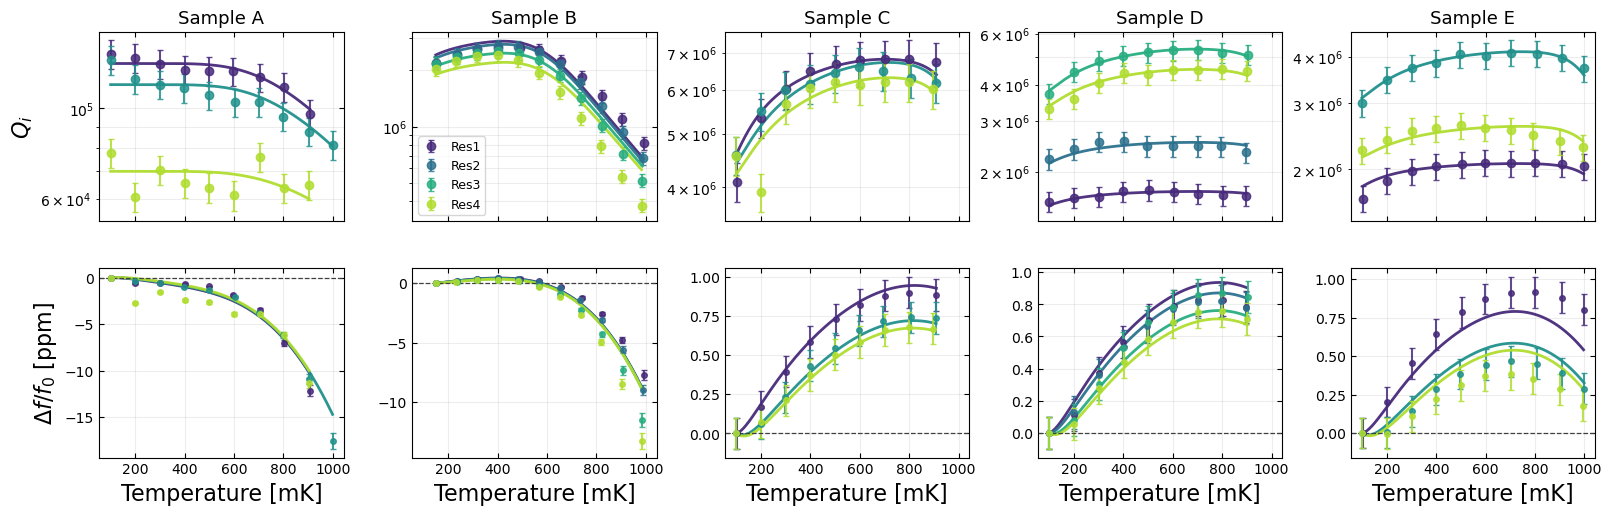

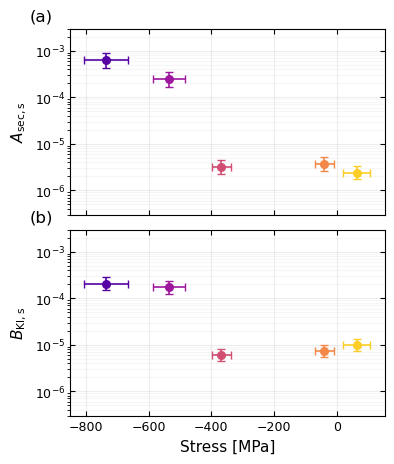

In [20]:
fig = plot_loss_freq_fixed_Tc2_fits(
    fixed_results,
    cmap_name="viridis",
    savepath="loss_frequency_fixed_Tc2_fits.pdf",
)
plt.show()

fig, amplitude_summary, amplitude_Tc_samples = estimate_amplitude_uncertainties_and_plot(
    fixed_results,
    n_Tc_samples=41,
    delta_chi2_level=1.0,
    cmap_name="plasma",
    figsize=(3.45*1.2, 3*1.5),
    savepath="amplitudes_vs_stress.pdf",
)
plt.show()